<a id="02"></a>

## 02 — Time Domain Analysis
### Phần đầu của mục 0.2 — Dạng sóng miền thời gian

**Mục đích**: so sánh Normal với ba loại lỗi Inner Race (IR), Outer Race
(OR) và Ball (B) tại tải **1 HP**. Các file lỗi dùng đường kính **14 mils**;
file Normal được chọn theo tải vì không có đường kính lỗi.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [2]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False  # manifest đã được build ở notebook 01

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Lấy sampling rate từ config, không hardcode
FS = cfg.SCOPE["sampling_rate_hz"]

In [3]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,NaN,NaN,False,12000.0
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,NaN,NaN,False,12000.0
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,NaN,NaN,False,12000.0
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,NaN,NaN,False,12000.0
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,NaN,NaN,False,12000.0


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [4]:
manifest = io_utils.apply_scope_filter(manifest)

# 1. Thống kê số lượng file ĐƯỢC SỬ DỤNG theo Nhãn (label) và Tải (load_hp)
used_data_stats = manifest.pivot_table(
    index="label", 
    columns="load_hp", 
    values="file_path",
    aggfunc="count", 
    fill_value=0
)

print("\nBảng thống kê dữ liệu được sử dụng trong dự án:")
print(used_data_stats)

# Xuất bảng thống kê ra file CSV
used_data_stats.to_csv(TABLES_DIR / "02_used_data_stats.csv")

# 2. (Tùy chọn) Xuất toàn bộ danh sách 40 file được sử dụng ra một file CSV riêng để dễ tra cứu
manifest.to_csv(TABLES_DIR / "02_used_data_manifest.csv", index=False)


Bảng thống kê dữ liệu được sử dụng trong dự án:
load_hp  0  1  2  3
label              
B        3  3  3  3
IR       3  3  3  3
Normal   1  1  1  1
OR       3  3  3  3


## Chọn file Normal và ba loại lỗi tại tải 1 HP

In [5]:
LOAD_HP = 1
DIAMETER_MILS = 14
FAULT_LABELS = ["IR", "OR", "B"]
PLOT_LABELS = ["Normal", *FAULT_LABELS]
label_colors = {
    "Normal": "tab:gray",
    "IR": "tab:red",
    "OR": "tab:blue",
    "B": "tab:green",
}

signals = {}
for label in PLOT_LABELS:
    pick_kwargs = {} if label == "Normal" else {"diameter_mils": DIAMETER_MILS}
    fp = pipeline.pick_file(
        manifest,
        label=label,
        load_hp=LOAD_HP,
        **pick_kwargs,
    )
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : ..\..\data\raw\Normal\98_Normal_1.mat  (483903 mẫu)
IR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\014\170_1.mat  (121846 mẫu)
OR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\014\198@6_1.mat  (122136 mẫu)
B       : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\186_1.mat  (122136 mẫu)


## Vẽ dạng sóng miền thời gian theo subplot

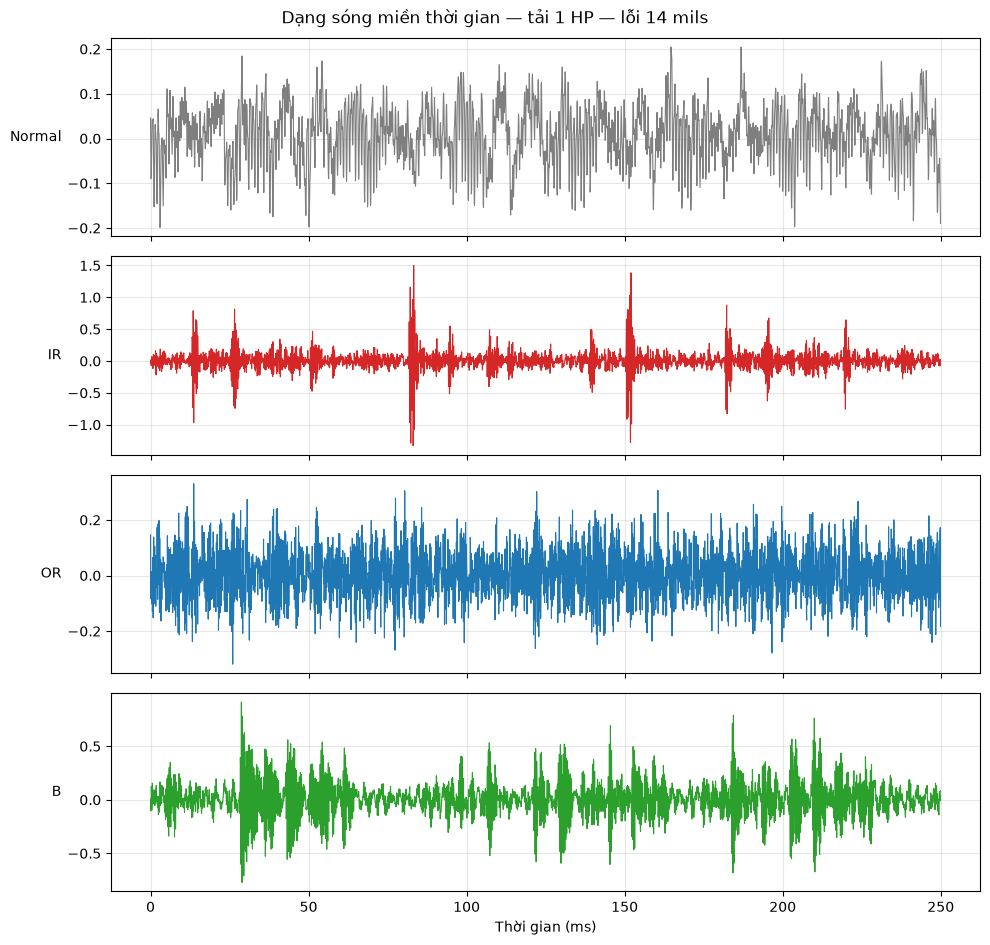

In [6]:
N_SECONDS = 0.25
fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.4 * len(signals)), sharex=True)
axes = np.atleast_1d(axes)
n_samples_limit = int(N_SECONDS * FS)

for ax, (label, x) in zip(axes, signals.items()):
    x_plot = x[:n_samples_limit]
    t_ms = np.arange(len(x_plot)) / FS * 1000
    ax.plot(t_ms, x_plot, linewidth=0.8, color=label_colors[label])
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(
    f"Dạng sóng miền thời gian — tải {LOAD_HP} HP — lỗi {DIAMETER_MILS} mils"
)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / f"02_time_4labels_load{LOAD_HP}hp_{DIAMETER_MILS:03d}mils.png",
    dpi=150,
)
plt.show()

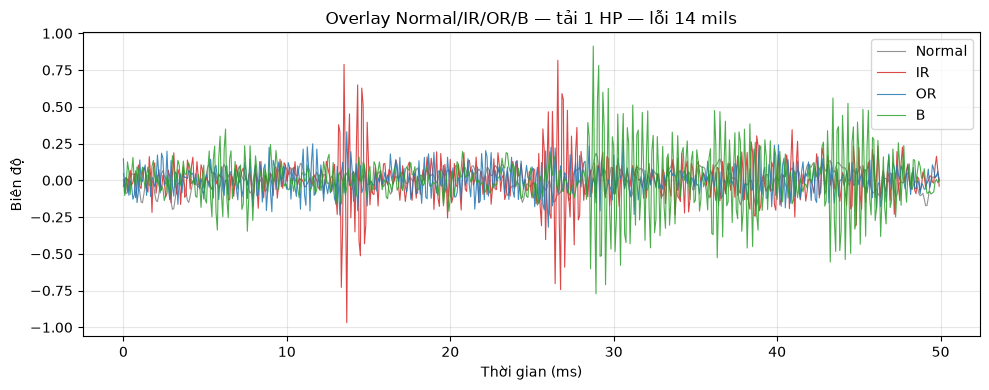

In [7]:
# Overlay bốn nhãn để so sánh trực tiếp biên độ.
N_SECONDS = 0.05
fig, ax = plt.subplots(figsize=(10, 4))
n_samples_limit = int(N_SECONDS * FS)

for label, x in signals.items():
    x_plot = x[:n_samples_limit]
    t_ms = np.arange(len(x_plot)) / FS * 1000
    ax.plot(
        t_ms, x_plot, linewidth=0.8, alpha=0.85,
        color=label_colors[label], label=label,
    )

ax.set_xlabel("Thời gian (ms)")
ax.set_ylabel("Biên độ")
ax.set_title(
    f"Overlay Normal/IR/OR/B — tải {LOAD_HP} HP — lỗi {DIAMETER_MILS} mils"
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / f"02_time_overlay_4labels_load{LOAD_HP}hp_{DIAMETER_MILS:03d}mils.png",
    dpi=150,
)
plt.show()

,rms,kurtosis,skewness,peak,std
label,,,,,
Normal,0.0664,-0.0694,-0.1730,0.3459,0.0652
IR,0.1655,19.0843,0.0030,2.0301,0.1655
OR,0.0936,-0.0597,0.0089,0.4016,0.0935
B,0.1409,5.8371,0.0157,1.3398,0.1408


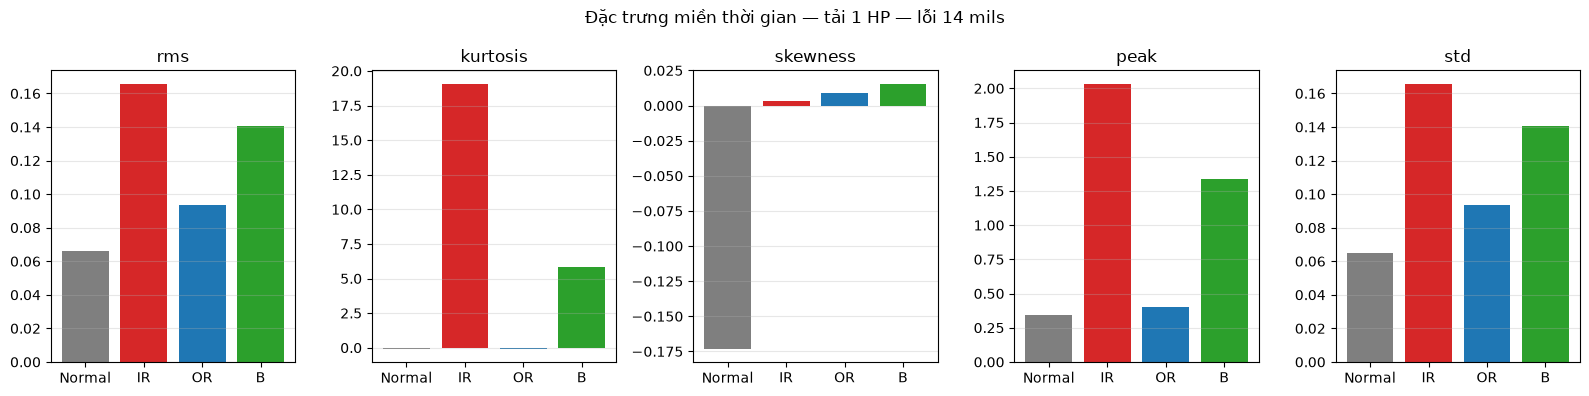

In [8]:
# Bảng đặc trưng miền thời gian cho Normal và ba loại lỗi.
feature_rows = []
for label, x in signals.items():
    feats = features.extract_simple_features(x)
    feature_rows.append({"label": label, **feats})

time_feature_df = pd.DataFrame(feature_rows).set_index("label")
time_feature_df.to_csv(TABLES_DIR / "02_time_domain_feature_table.csv")
display(time_feature_df.round(4))

feature_names = list(time_feature_df.columns)
fig, axes = plt.subplots(1, len(feature_names), figsize=(3.2 * len(feature_names), 4))
if len(feature_names) == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_names):
    values = time_feature_df[feat]
    bar_colors = [label_colors.get(lbl, "black") for lbl in values.index]
    ax.bar(values.index, values.values, color=bar_colors)
    ax.set_title(feat)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle(
    f"Đặc trưng miền thời gian — tải {LOAD_HP} HP — lỗi {DIAMETER_MILS} mils"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_feature_comparison.png", dpi=150)
plt.show()

## Quan sát

Điền nhận xét sau khi chạy với dữ liệu CWRU:
- Normal khác IR, OR và B về biên độ và tính xung như thế nào?
- Loại lỗi nào có peak hoặc kurtosis lớn nhất?

Tải so sánh: 1 HP. Các file lỗi: 14 mils. Hình subplot lưu tại
`outputs/figures/02_time_4labels_load1hp_014mils.png`.